In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

from sklearn.metrics import r2_score
from scipy.special import rel_entr

from biological_fuzzy_logic_networks.manuscripts_functions.colors import models_dict
from biological_fuzzy_logic_networks.manuscripts_functions.metrics import compute_scalar_mmd, wasserstein_distance

In [2]:
fontsize = 12

In [3]:
sns.set_theme(font="Arial", style="ticks", rc={"font.size": fontsize,"axes.titlesize":fontsize,"axes.labelsize":fontsize, 
                                               "xtick.labelsize": fontsize, "ytick.labelsize": fontsize, "legend.fontsize": fontsize})
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.size'] = fontsize


In [4]:
def compute_MMD(data):
    data["cell_id"] = len(data['marker'].unique())*[i for i in range(int(len(data)/len(data["marker"].unique())))] 
    
    pred = data[["cell_id", "marker", "pred"]]
    pred = pred.set_index("cell_id").pivot(columns="marker") 
    
    true = data[["cell_id", "marker", "true"]]
    true = true.set_index("cell_id").pivot(columns="marker")
    
    mmd = compute_scalar_mmd(true, pred)
    
    return mmd


def compute_wasserstein(data):
    data["cell_id"] = len(data['marker'].unique())*[i for i in range(int(len(data)/len(data["marker"].unique())))] 
    
    pred = data[["cell_id", "marker", "pred"]]
    pred = pred.set_index("cell_id").pivot(columns="marker")
    
    
    true = data[["cell_id", "marker", "true"]]
    true = true.set_index("cell_id").pivot(columns="marker")
    emd = wasserstein_distance(true, pred)
    
    return emd

def compute_R2(data):
    out = r2_score(data["true"], data['pred'])
    return out

In [5]:
base_dir = "/Users/adr/Box/BioFuzzNet/BFN/Model/MeasuredNodes/"
max_nodes = 13
n_repeats = 5
input_nodes = ["igf1", "il1a", "tgfa", "tnfa"]

In [6]:
all_data = []
n_sel_nodes = []
n_repeat = []
for i in range(max_nodes):
    for j in range(n_repeats):
        try:
            data = pd.read_csv(f"{base_dir}{i+1}_nodes/{j+1}_unperturbed.csv", index_col=1)
            all_data.append(data)
            n_sel_nodes = n_sel_nodes + [i+1]*len(data)
            n_repeat = n_repeat + [j+1]*len(data)
        except:
            print("Node ", i+1, "repeat", j+1, "missing")

In [7]:
res = pd.concat(all_data)
res["number of nodes observed"] = n_sel_nodes
res["n_repeat"] = n_repeat
res = res.rename(columns={"Unnamed: 0": "model"})

# Linear model can't do OOD predictions so can't predict the unobserved nodes
res = res[~res["model"].isin(["lm_same_input", "lm_random_input"])]
res

,model,mek12,erk12,mkk4,jnk12,ikk,ikb,ras,map3k7,pi3k,map3k1,akt,p38,hsp27,number of nodes observed,n_repeat
0,teacher_true,0.554041,0.656667,0.093493,0.099612,0.999934,1.000000,0.672717,0.983857,0.999894,0.375915,1.000000,0.050208,0.013427,1,1
1,teacher_true,0.409098,0.424542,0.046511,0.045472,0.999894,1.000000,0.631068,0.983779,0.999547,0.254872,1.000000,0.023272,0.003596,1,1
2,teacher_true,0.027666,0.017263,0.998448,1.000000,1.000000,1.000000,0.312202,0.994853,0.999971,0.974393,1.000000,0.999999,1.000000,1,1
3,teacher_true,0.115754,0.081464,0.800585,0.983286,0.999969,1.000000,0.483537,0.872489,0.985945,0.853267,0.999826,0.927253,0.988329,1,1
4,teacher_true,0.042362,0.026964,0.025404,0.012733,0.618345,0.750013,0.364208,0.533889,0.832253,0.295221,0.931161,0.006761,0.000275,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,nohill_random_input,0.051483,0.029062,0.147198,0.151236,0.797210,0.705200,0.089433,0.835993,0.914069,0.300256,0.874010,0.066317,0.029233,13,5
1996,nohill_random_input,0.822527,0.740197,0.756283,0.805580,0.982874,0.977450,0.879658,0.907332,0.998643,0.915045,0.998598,0.562079,0.536875,13,5
1997,nohill_random_input,0.476964,0.342090,0.118077,0.115269,0.720091,0.604565,0.610823,0.762822,0.997761,0.280516,0.997571,0.045484,0.022569,13,5
1998,nohill_random_input,0.958265,0.941036,0.275935,0.192412,0.797732,0.705913,0.969760,0.562096,0.998891,0.754824,0.998878,0.074744,0.056520,13,5


In [8]:
res["model"].unique()

array(['teacher_true', 'student_same_input', 'student_random_input',
       'nohill_same_input', 'nohill_random_input'], dtype=object)

In [9]:
true = res.loc[res["model"]=="teacher_true", [c for c in res.columns if not c in input_nodes]]
pred = res.loc[res["model"]!="teacher_true", [c for c in res.columns if not c in input_nodes]]

In [10]:
true_long = true.reset_index().melt(id_vars = ["index", "model", "number of nodes observed", "n_repeat"], 
                                    var_name="marker", value_name="true")
true_long = true_long.drop("model", axis=1)
pred_long = pred.reset_index().melt(id_vars = ["index", "model", "number of nodes observed", "n_repeat"], 
                                    var_name="marker", value_name="pred")


In [11]:
all_long =  pred_long.merge(true_long, on=["index", "number of nodes observed", 'n_repeat', "marker"], how="left")
all_long = all_long.dropna(axis=0, how="any")
all_long["true"] = all_long["true"].astype(float)

In [12]:
all_long["sq_err"] = (all_long["true"] - all_long["pred"])**2

In [13]:
all_per_run = all_long[["model", "number of nodes observed", 'n_repeat', "marker", "sq_err"]].groupby(["model", "number of nodes observed", 'n_repeat', "marker"]).mean()
all_per_run

sq_err
model               number of nodes observed n_repeat marker              
nohill_random_input 1                        1        akt     1.063517e-01
                                                      erk12   2.707286e-01
                                                      hsp27   3.743763e-01
                                                      ikb     2.618703e-01
                                                      ikk     1.871472e-01
...                                                                    ...
student_same_input  13                       5        mek12   4.790378e-11
                                                      mkk4    1.602167e-06
                                                      p38     3.335528e-06
                                                      pi3k    6.956019e-05
                                                      ras     7.756962e-10

[3380 rows x 1 columns]

In [14]:
all_long.groupby(["number of nodes observed", "n_repeat", "model"]).size()

number of nodes observed  n_repeat  model               
1                         1         nohill_random_input     26000
                                    nohill_same_input       26000
                                    student_random_input    26000
                                    student_same_input      26000
                          2         nohill_random_input     26000
                                                            ...  
13                        4         student_same_input      26000
                          5         nohill_random_input     26000
                                    nohill_same_input       26000
                                    student_random_input    26000
                                    student_same_input      26000
Length: 260, dtype: int64

In [15]:
true_long.groupby(["number of nodes observed", "n_repeat"]).size()

number of nodes observed  n_repeat
1                         1           26000
                          2           26000
                          3           26000
                          4           26000
                          5           26000
                                      ...  
13                        1           26000
                          2           26000
                          3           26000
                          4           26000
                          5           26000
Length: 65, dtype: int64

In [16]:
all_per_run = all_per_run.rename(columns={"sq_err": "MSE"})

In [17]:
all_per_run["R2"] = all_long.groupby(["model", "number of nodes observed", "n_repeat", "marker"]).apply(compute_R2)

In [18]:
all_per_run = all_per_run.reset_index()

In [19]:
per_run_network = all_per_run.groupby(["number of nodes observed", "n_repeat", "model"]).mean(numeric_only=True)
per_run_network = per_run_network.rename(columns={"MSE": "Network MSE", "R2": "Network R2"})
per_run_network

Network MSE  \
number of nodes observed n_repeat model                               
1                        1        nohill_random_input      0.237619   
                                  nohill_same_input        0.068339   
                                  student_random_input     0.261440   
                                  student_same_input       0.016193   
                         2        nohill_random_input      0.259645   
...                                                             ...   
13                       4        student_same_input       0.000003   
                         5        nohill_random_input      0.248647   
                                  nohill_same_input        0.062609   
                                  student_random_input     0.293992   
                                  student_same_input       0.000008   

                                                        Network R2  
number of nodes observed n_repeat model                             
1                        1        nohill_random_input    -1.137857  
                                  nohill_same_input       0.392212  
                                  student_random_input   -1.056956  
                                  student_same_input      0.874179  
                         2        nohill_random_input    -0.808340  
...                                                            ...  
13                       4        student_same_input      0.999961  
                         5        nohill_random_input    -0.740506  
                                  nohill_same_input       0.634969  
                                  student_random_input   -0.990661  
                                  student_same_input      0.999843  

[260 rows x 2 columns]

In [20]:
all_long

,index,model,number of nodes observed,n_repeat,marker,pred,true,sq_err
0,0,student_same_input,1,1,mek12,0.863995,0.554041,0.096072
1,1,student_same_input,1,1,mek12,0.826954,0.409098,0.174604
2,2,student_same_input,1,1,mek12,0.426091,0.027666,0.158743
3,3,student_same_input,1,1,mek12,0.662650,0.115754,0.299096
4,4,student_same_input,1,1,mek12,0.500974,0.042362,0.210325
...,...,...,...,...,...,...,...,...
6759995,1995,nohill_random_input,13,5,hsp27,0.029233,0.444513,0.172458
6759996,1996,nohill_random_input,13,5,hsp27,0.536875,0.000008,0.288226
6759997,1997,nohill_random_input,13,5,hsp27,0.022569,0.000035,0.000508
6759998,1998,nohill_random_input,13,5,hsp27,0.056520,0.010591,0.002109


In [21]:
per_run_network["MMD"] = all_long.groupby(["number of nodes observed", "n_repeat", "model"]).apply(compute_MMD)
per_run_network["EMD"] = all_long.groupby(["number of nodes observed", "n_repeat", "model"]).apply(compute_wasserstein)

In [22]:
per_run_network["EMD"] = per_run_network["EMD"].astype(float)
per_run_network = per_run_network.reset_index()

# Same inputs

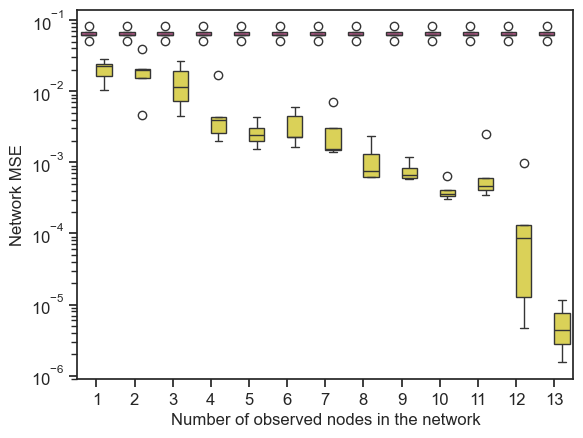

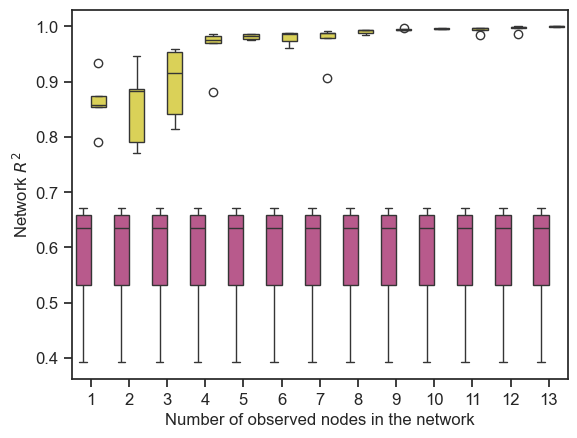

In [23]:
sns.boxplot(data=per_run_network[per_run_network["model"].isin(["nohill_same_input", "student_same_input", "lm_same_input"])], 
            x="number of nodes observed", y="Network MSE", hue="model", palette=models_dict)
plt.legend([], [], frameon=False)
plt.xlabel("Number of observed nodes in the network")
plt.ylabel("Network MSE")
plt.yscale("log")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Measured_nodes_Network_MSE_same_inputs_per_n_measured.pdf", bbox_inches="tight")
plt.show()

sns.boxplot(data=per_run_network[per_run_network["model"].isin(["nohill_same_input", "student_same_input"])], 
            x="number of nodes observed", y="Network R2", hue="model", palette=models_dict)
# plt.ylim((-3e4, 2))
plt.xlabel("Number of observed nodes in the network")
plt.ylabel("Network $R^2$")
# plt.yscale("log")
plt.legend([], [], frameon=False)
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Measured_nodes_Network_R2_same_inputs_per_n_measured.pdf", bbox_inches="tight")
plt.show()


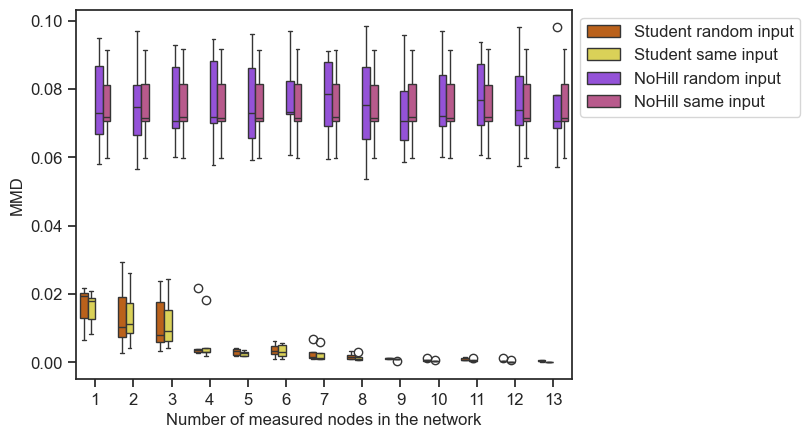

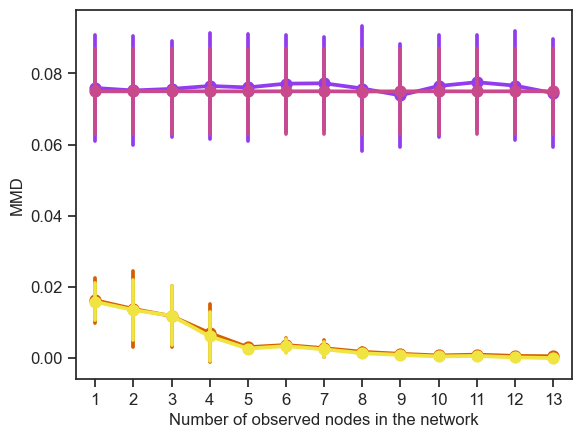

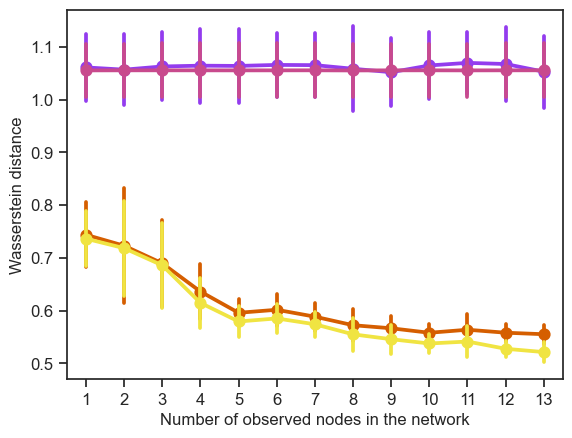

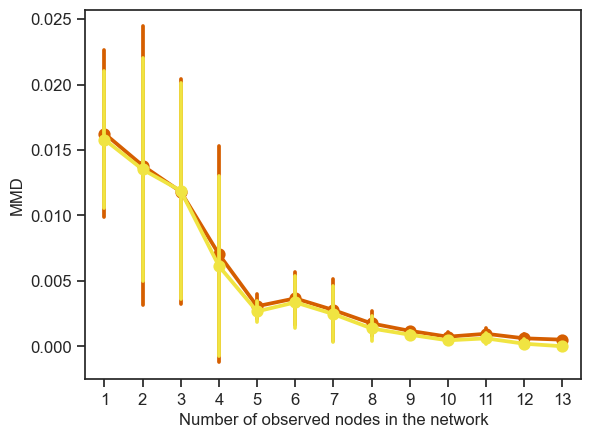

In [24]:
g = sns.boxplot(data=per_run_network, x="number of nodes observed", 
            y="MMD", hue="model", palette=models_dict, hue_order=[
                "student_random_input", "student_same_input", "nohill_random_input", "nohill_same_input"
            ])
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel("Number of measured nodes in the network")
new_labels = ["Student random input", "Student same input", "NoHill random input", "NoHill same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
# plt.yscale("symlog")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Measured_nodes_MMD_legend.pdf", bbox_inches="tight")
plt.show()

sns.pointplot(data=per_run_network, x="number of nodes observed", 
            y="MMD", hue="model", palette=models_dict, errorbar="sd")
plt.legend([], [], frameon=False)
plt.xlabel("Number of observed nodes in the network")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Measured_nodes_MMD_per_n_measured.pdf", bbox_inches="tight")
plt.show()

sns.pointplot(data=per_run_network, x="number of nodes observed", 
            y="EMD", hue="model", palette=models_dict, errorbar="sd")
plt.legend([], [], frameon=False)
plt.xlabel("Number of observed nodes in the network")
plt.ylabel("Wasserstein distance")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Measured_nodes_EMD_per_n_measured.pdf", bbox_inches="tight")
plt.show()

sns.pointplot(data=per_run_network[per_run_network["model"].isin(["student_same_input", "student_random_input"])], 
              x="number of nodes observed",  y="MMD", hue="model", palette=models_dict, errorbar="sd")
plt.legend([], [], frameon=False)
plt.xlabel("Number of observed nodes in the network")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Measured_nodes_MMD_student_only_per_n_measured.pdf", bbox_inches="tight")
plt.show()